In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
df = pd.read_csv("adm_data.csv")

# Clean column names (remove extra spaces)
df.columns = [c.strip() for c in df.columns]

# Drop Serial No. as it is just an ID, not a feature
df = df.drop(columns=["Serial No."])

df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [12]:
print("Shape of dataset:", df.shape)
df.info()

Shape of dataset: (400, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GRE Score          400 non-null    int64  
 1   TOEFL Score        400 non-null    int64  
 2   University Rating  400 non-null    int64  
 3   SOP                400 non-null    float64
 4   LOR                400 non-null    float64
 5   CGPA               400 non-null    float64
 6   Research           400 non-null    int64  
 7   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 25.1 KB


In [13]:
#  Univariate Analysis

#1 Summary Statistics
#Basic descriptive statistics for every column: mean, std, min, max, quartiles.

df.describe()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,316.807500,107.410000,3.087500,3.400000,3.452500,8.598925,0.547500,0.724350
std,11.473646,6.069514,1.143728,1.006869,0.898478,0.596317,0.498362,0.142609
min,290.000000,92.000000,1.000000,1.000000,1.000000,6.800000,0.000000,0.340000
25%,308.000000,103.000000,2.000000,2.500000,3.000000,8.170000,0.000000,0.640000
50%,317.000000,107.000000,3.000000,3.500000,3.500000,8.610000,1.000000,0.730000
75%,325.000000,112.000000,4.000000,4.000000,4.000000,9.062500,1.000000,0.830000
max,340.000000,120.000000,5.000000,5.000000,5.000000,9.920000,1.000000,0.970000


In [14]:
# Central Tendency and Spread (per feature)
# Mean, median, standard deviation, skewness for each numeric column.
summary = pd.DataFrame({
    "mean": df.mean(),
    "median": df.median(),
    "std": df.std(),
    "skewness": df.skew()
})
summary

,mean,median,std,skewness
GRE Score,316.807500,317.00,11.473646,-0.062893
TOEFL Score,107.410000,107.00,6.069514,0.057216
University Rating,3.087500,3.00,1.143728,0.171260
SOP,3.400000,3.50,1.006869,-0.275761
LOR,3.452500,3.50,0.898478,-0.106991
CGPA,8.598925,8.61,0.596317,-0.065991
Research,0.547500,1.00,0.498362,-0.191582
Chance of Admit,0.724350,0.73,0.142609,-0.353448


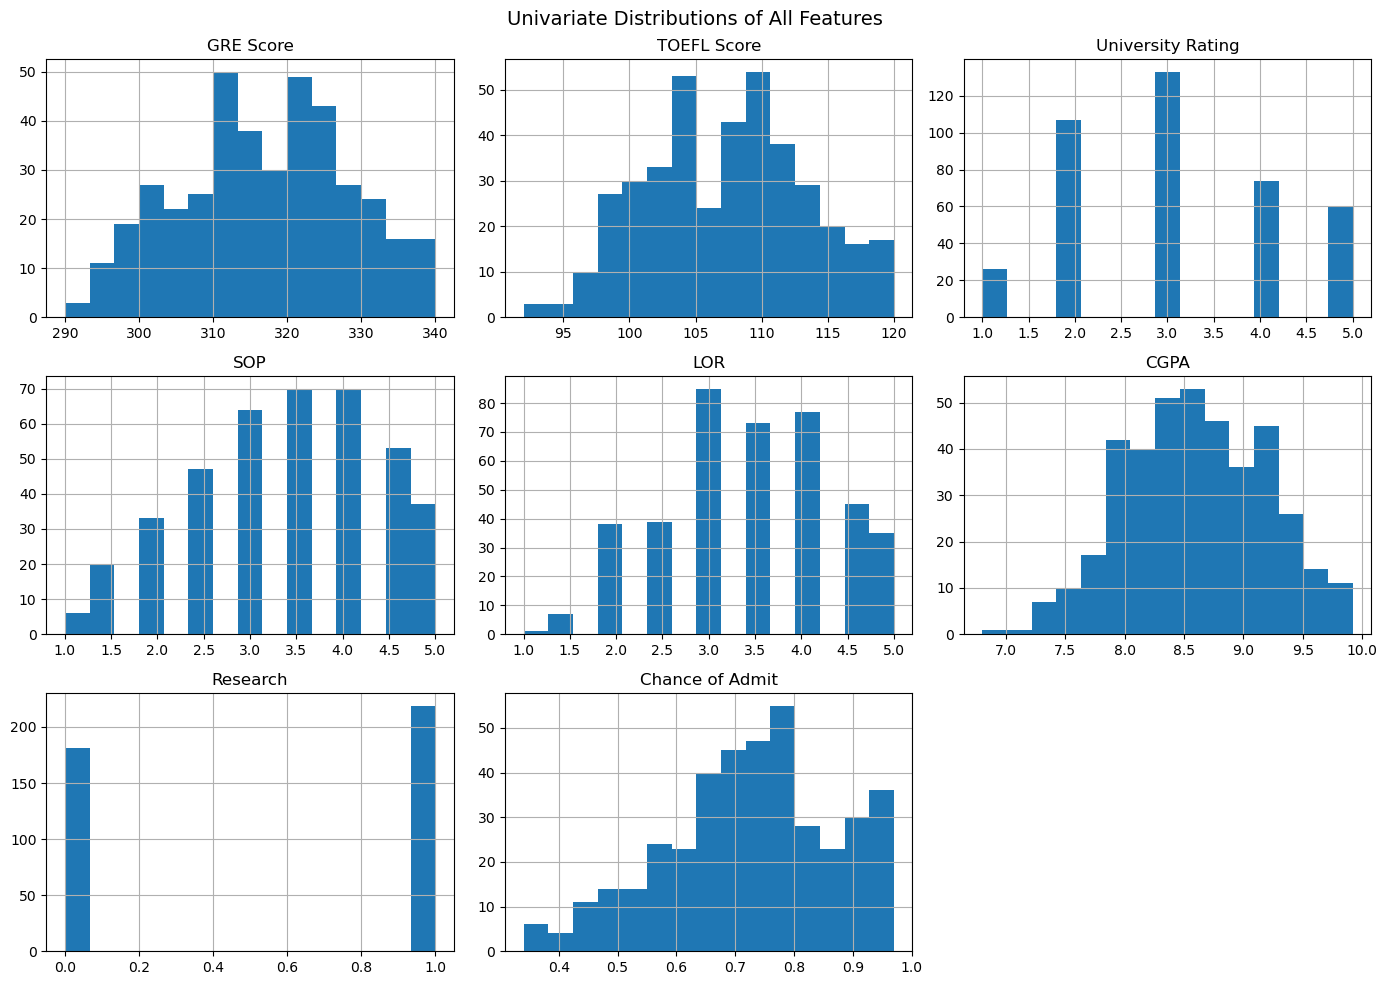

In [21]:
#  Histograms
# Distribution of each individual feature.
df.hist(bins=15, figsize=(14, 10))
plt.suptitle("Univariate Distributions of All Features", fontsize=14)
plt.tight_layout()
plt.show()

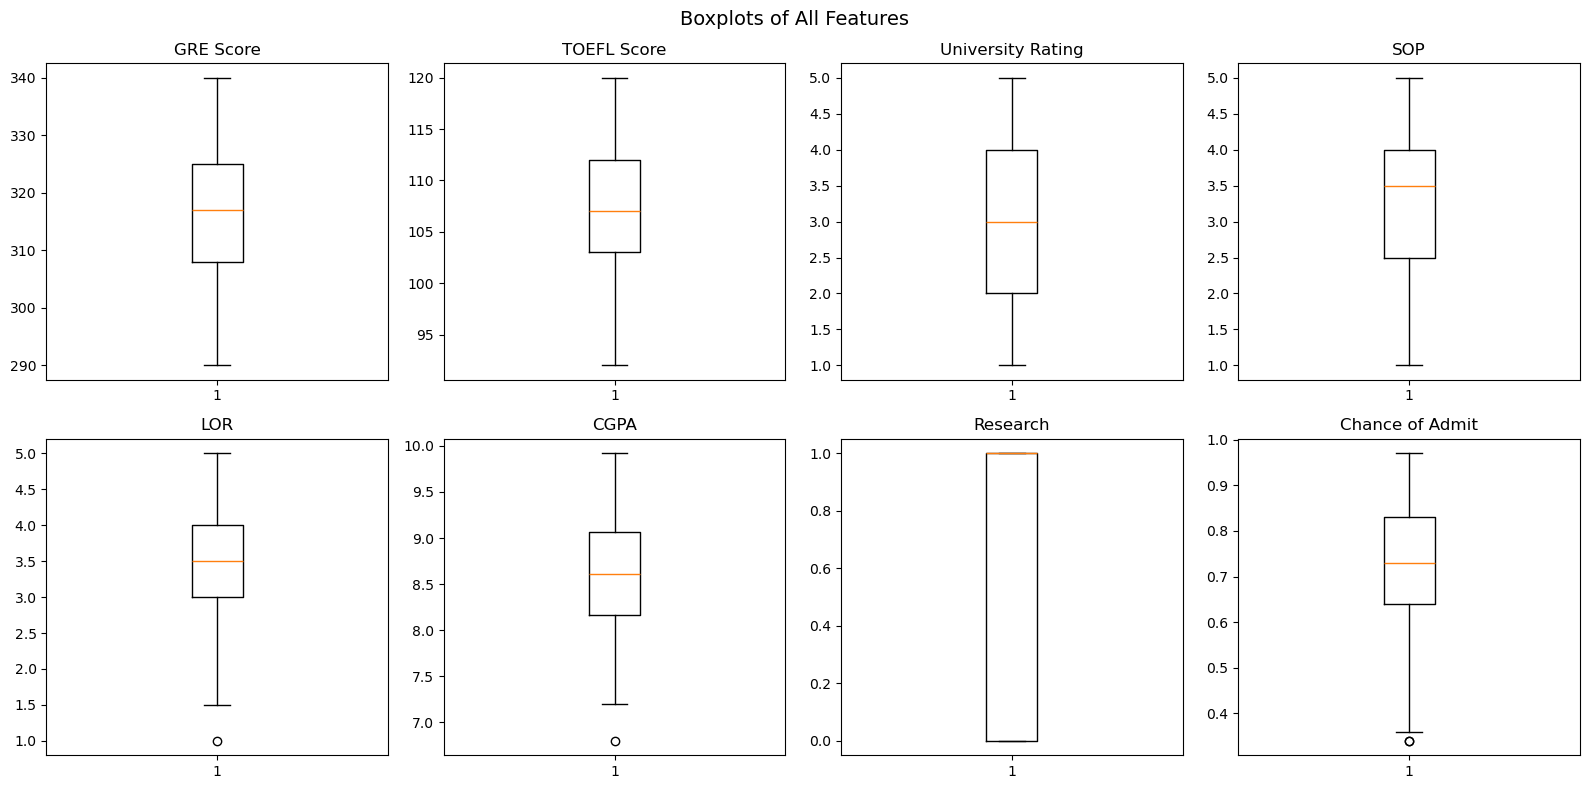

In [16]:
#  Boxplots
#  Boxplot per feature to see spread and any obvious extreme values.
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].boxplot(df[col], vert=True)
    axes[i].set_title(col)

plt.suptitle("Boxplots of All Features", fontsize=14)
plt.tight_layout()
plt.show()

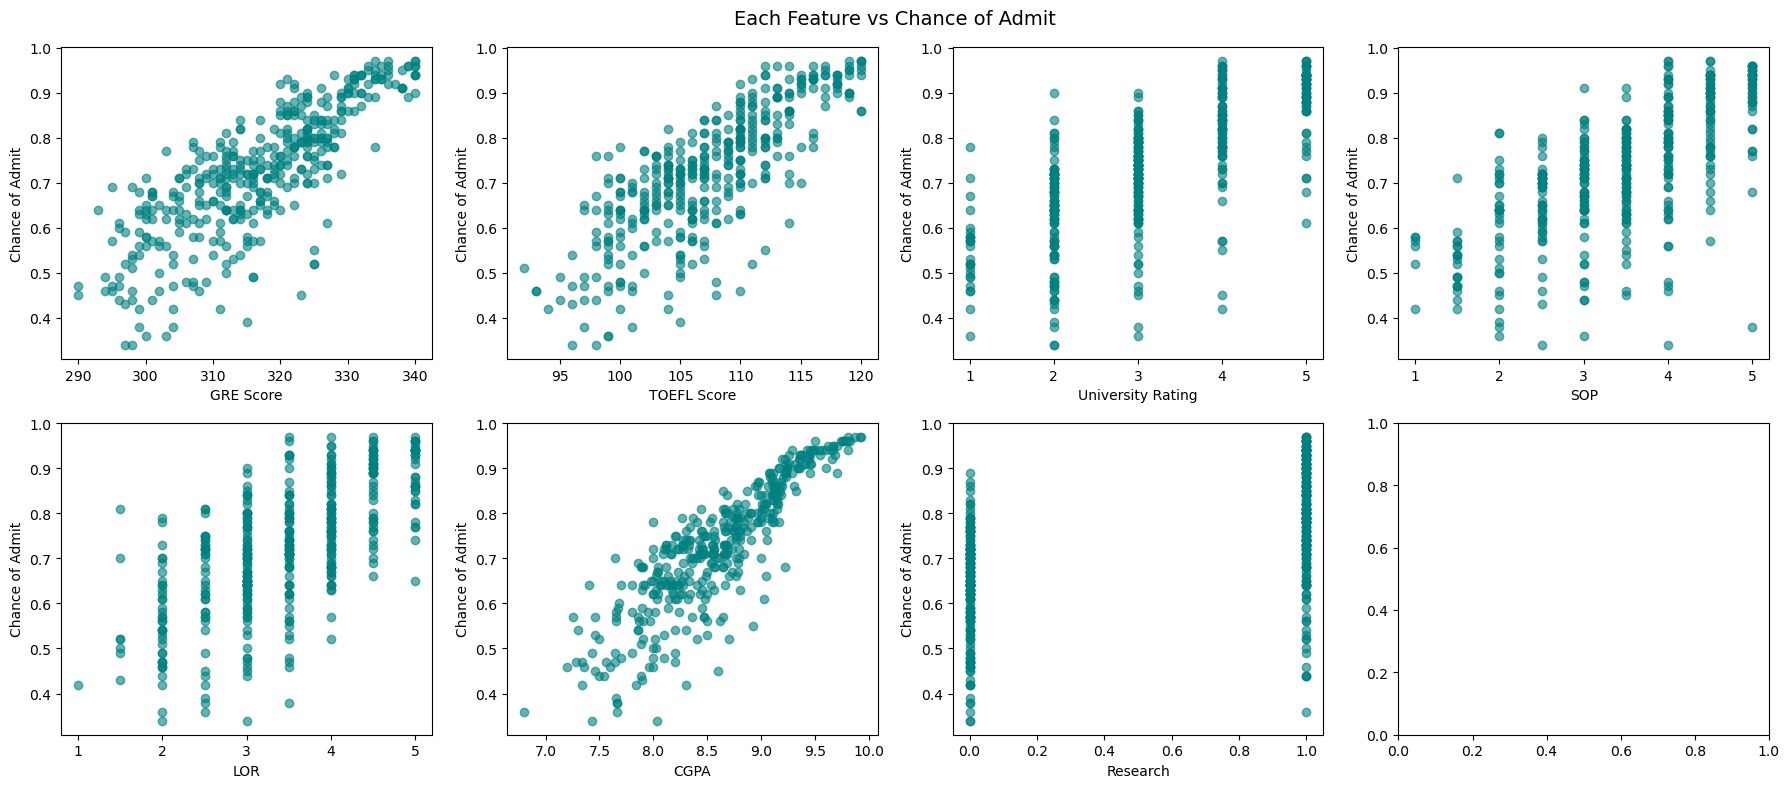

In [17]:
# 3. Multivariate Analysis

# Pairwise Scatter Plots
# How each feature relates to the target variable `Chance of Admit`.

features = [c for c in df.columns if c != "Chance of Admit"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].scatter(df[col], df["Chance of Admit"], alpha=0.6, color="teal")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Chance of Admit")

plt.suptitle("Each Feature vs Chance of Admit", fontsize=14)
plt.tight_layout()
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15216\4124639909.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([research_no, research_yes], labels=["No Research", "Research"])


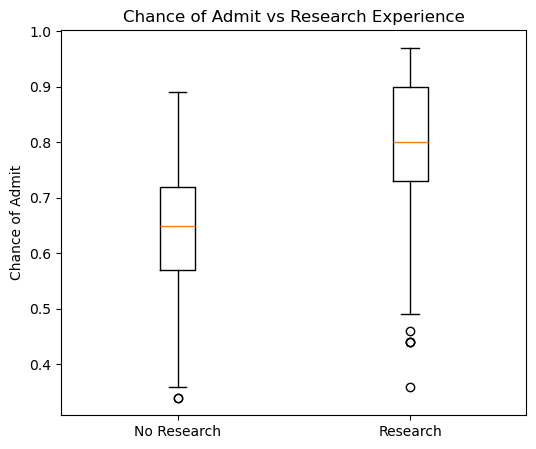

Average Chance of Admit (Research): 0.796
Average Chance of Admit (No Research): 0.638


In [18]:
#  Effect of Research Experience
# Comparing admission chance for applicants with and without research experience.
research_yes = df[df["Research"] == 1]["Chance of Admit"]
research_no = df[df["Research"] == 0]["Chance of Admit"]

plt.figure(figsize=(6, 5))
plt.boxplot([research_no, research_yes], labels=["No Research", "Research"])
plt.ylabel("Chance of Admit")
plt.title("Chance of Admit vs Research Experience")
plt.show()

print("Average Chance of Admit (Research):", round(research_yes.mean(), 3))
print("Average Chance of Admit (No Research):", round(research_no.mean(), 3))

In [19]:
## 4. Observations

# Most features (GRE, TOEFL, CGPA) are close to normally distributed with a slight left skew.
# Chance of Admit shows a strong positive relationship with CGPA, GRE Score, and TOEFL Score
# Applicants with research experience tend to have a higher average chance of admission.
# These patterns confirm that CGPA, GRE, and TOEFL are likely to be the strongest predictors, useful for the modeling stage.